In [ ]:
from google.colab import files
uploaded = files.upload()

Saving brain_tumor_dataset.zip to brain_tumor_dataset (1).zip


In [ ]:
!unzip brain_tumor_dataset.zip

Archive:  brain_tumor_dataset.zip
   creating: brain_tumor_dataset/
   creating: brain_tumor_dataset/no/
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_datase

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns

In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    'brain_tumor_dataset',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    'brain_tumor_dataset',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

CLASS_NAMES = {v: k for k, v in train_data.class_indices.items()}
print('Classes:', train_data.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Classes: {'no': 0, 'yes': 1}


In [ ]:
## 5. CNN Model
from tensorflow.keras import Input

inp = Input(shape=(128, 128, 3))
x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1')(inp)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_last')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_last (Conv2D)             │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 991ms/step - accuracy: 0.6749 - loss: 0.7707 - val_accuracy: 0.7400 - val_loss: 0.5473
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7734 - loss: 0.5121 - val_accuracy: 0.7400 - val_loss: 0.6400
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8030 - loss: 0.4663 - val_accuracy: 0.7600 - val_loss: 0.5677
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8079 - loss: 0.4491 - val_accuracy: 0.7400 - val_loss: 0.5270
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8325 - loss: 0.4493 - val_accuracy: 0.7600 - val_loss: 0.5609
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8325 - loss: 0.4318 - val_accuracy: 0.7400 - val_loss: 0.6002
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8670 - loss: 0.3403 - val_accuracy: 0.7400 - val_loss: 0.5325
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8768 - loss: 0.3349 - val_accuracy: 0.7800 - val_loss: 0.5230
Epoch 9/1

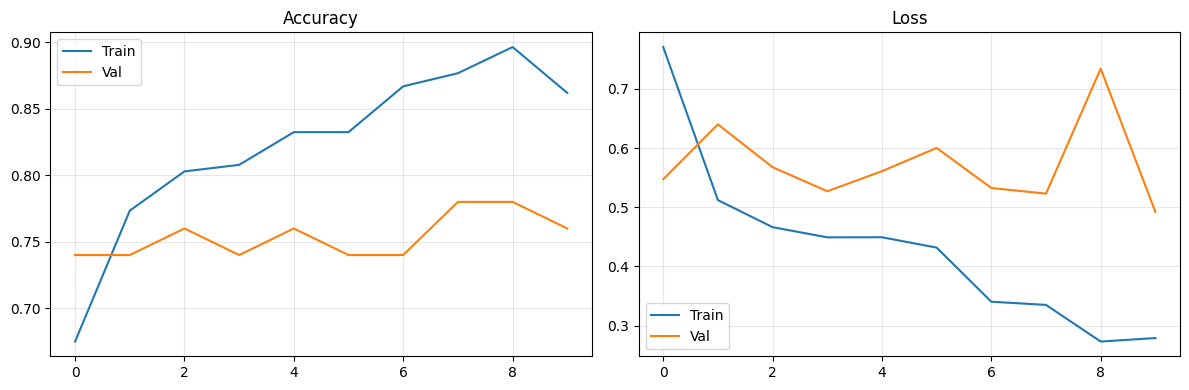

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],         label='Train')
plt.plot(history.history['val_loss'],     label='Val')
plt.title('Loss'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
val_data.reset()
y_true = val_data.classes
y_prob = model.predict(val_data, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Validation Accuracy
loss, acc = model.evaluate(val_data, verbose=0)
print(f'Validation Accuracy : {acc:.4f}')
print(f'ROC-AUC             : {roc_auc_score(y_true, y_prob):.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['No Tumor', 'Tumor']))

Validation Accuracy : 0.7600
ROC-AUC             : 0.8234

              precision    recall  f1-score   support

    No Tumor       0.71      0.63      0.67        19
       Tumor       0.79      0.84      0.81        31

    accuracy                           0.76        50
   macro avg       0.75      0.74      0.74        50
weighted avg       0.76      0.76      0.76        50



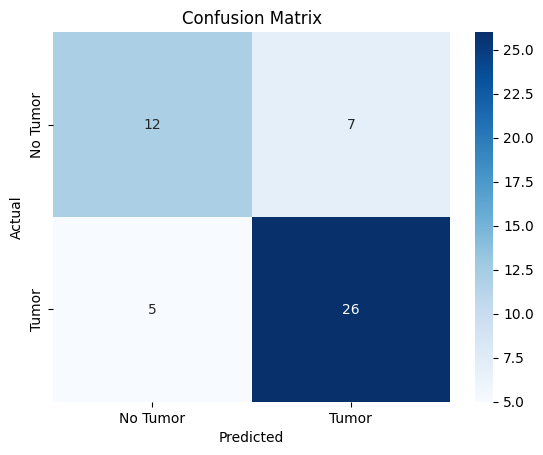

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

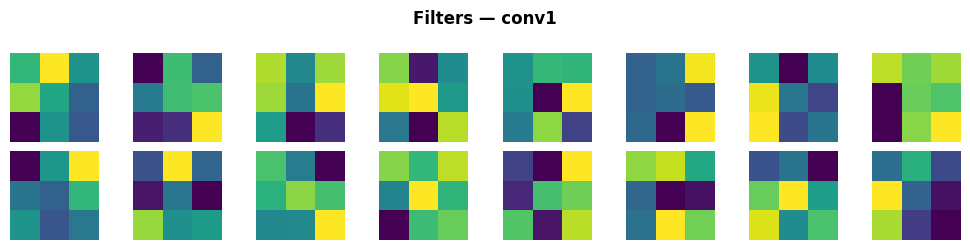

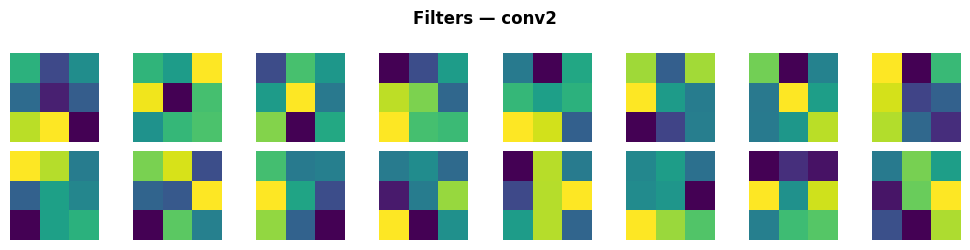

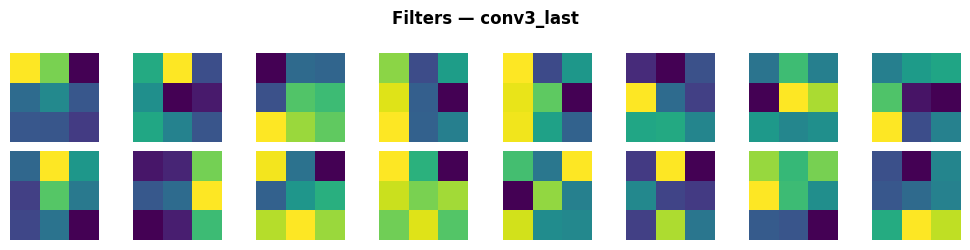

In [ ]:
for layer_name in ['conv1', 'conv2', 'conv3_last']:
    filters = model.get_layer(layer_name).get_weights()[0]  # (3,3,in,out)
    n = min(16, filters.shape[-1])

    # Normalize
    f = filters - filters.min()
    f = f / (f.max() + 1e-8)

    plt.figure(figsize=(10, 2.5))
    plt.suptitle(f'Filters — {layer_name}', fontweight='bold')
    for i in range(n):
        plt.subplot(2, 8, i+1)
        plt.imshow(f[:,:,:,i].mean(axis=-1), cmap='viridis')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def get_gradcam(model, img_array, layer_name='conv3_last'):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads       = tape.gradient(loss, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap     = tf.nn.relu(conv_out[0] @ pooled[..., tf.newaxis])
    heatmap     = heatmap.numpy().squeeze()
    heatmap     = heatmap / (heatmap.max() + 1e-8)
    return heatmap

print('Grad-CAM function ready')

Grad-CAM function ready


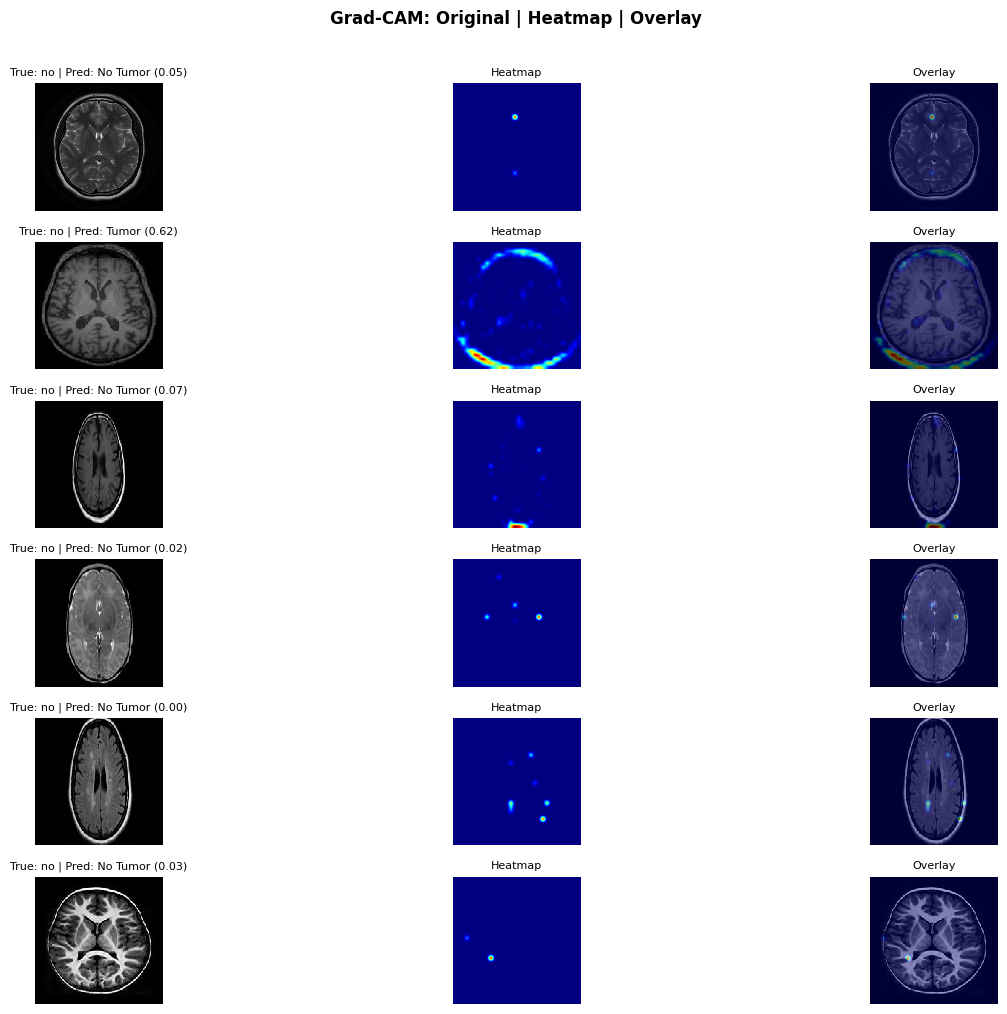

In [ ]:
val_data.reset()
imgs, labels = next(val_data)

plt.figure(figsize=(15, 10))
for i in range(6):
    img   = imgs[i]
    inp   = np.expand_dims(img, 0)
    prob  = model.predict(inp, verbose=0)[0][0]
    pred  = 'Tumor' if prob >= 0.5 else 'No Tumor'
    true  = CLASS_NAMES[int(labels[i])]

    heatmap = get_gradcam(model, inp)
    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.6 * np.uint8(img*255) + 0.4 * heatmap_color)

    # Original
    plt.subplot(6, 3, i*3+1)
    plt.imshow(img)
    plt.title(f'True: {true} | Pred: {pred} ({prob:.2f})', fontsize=8)
    plt.axis('off')

    # Heatmap
    plt.subplot(6, 3, i*3+2)
    plt.imshow(heatmap_color)
    plt.title('Heatmap', fontsize=8)
    plt.axis('off')

    # Overlay
    plt.subplot(6, 3, i*3+3)
    plt.imshow(overlay)
    plt.title('Overlay', fontsize=8)
    plt.axis('off')

plt.suptitle('Grad-CAM: Original | Heatmap | Overlay', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

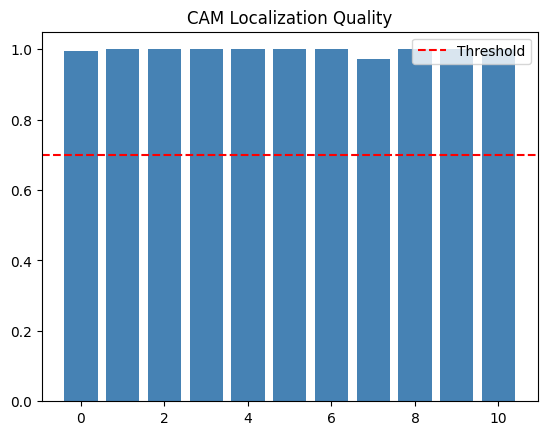

In [ ]:
## 11. Localization Quality
val_data.reset()
imgs, labels = next(val_data)

scores = []
for img, lbl in zip(imgs, labels):
    inp  = np.expand_dims(img, 0)
    prob = model.predict(inp, verbose=0)[0][0]
    if int(lbl) == 1 and prob >= 0.5:
        h    = get_gradcam(model, inp).ravel()
        scores.append(np.sort(h)[::-1][:len(h)//2].sum() / (h.sum() + 1e-8))

plt.bar(range(len(scores)), scores, color='steelblue')
plt.axhline(0.7, color='red', linestyle='--', label='Threshold')
plt.title('CAM Localization Quality'); plt.legend(); plt.show()